In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers, initializers

In [3]:
from tensorflow.keras.datasets import cifar100

In [4]:
(x_train,y_train),(x_test,y_test)=cifar100.load_data(label_mode='fine')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [5]:
x_train=x_train/255
x_test= x_test/255

In [6]:
from sklearn.metrics import*

/tmp/ipython-input-40148130.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(int(y_train[i]))


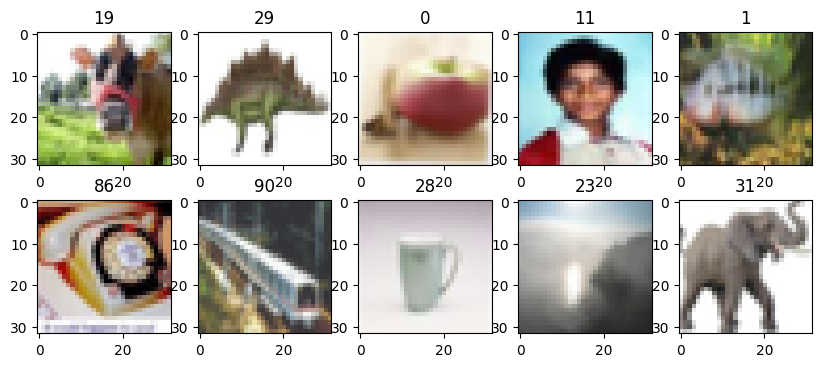

In [7]:
plt.figure(figsize=(10,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  img = x_train[i]
  plt.imshow((img*255).astype('uint8') if img.max()<=1 else img)

  plt.title(int(y_train[i]))
plt.show()

In [8]:
data_augmentation= tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.06),
    layers.RandomTranslation(0.06, 0.06),
    layers.RandomZoom(0.06),

], name='data_augmentation')

In [9]:
def build_model(input_shape=(32,32,3), num_classes=100, dropout_rate=0.4):
  he = initializers.HeNormal()
  inputs= layers.Input(shape=input_shape)

  x= data_augmentation(inputs)

  x = layers.Conv2D(64, 3, padding='same', kernel_initializer= he)(x)
  x = layers.BatchNormalization()(x);
  x = layers.ReLU()(x)
  x = layers.Conv2D(64, 3, padding='same', kernel_initializer= he)(x)
  x = layers.BatchNormalization()(x);
  x = layers.ReLU()(x)
  x = layers.MaxPooling2D()(x);
  x = layers.Dropout(0.25)(x)


  x =layers.Conv2D(128, 3, padding='same', kernel_initializer= he)(x)
  x= layers.BatchNormalization()(x);
  x=layers.ReLU()(x)
  x=layers.Conv2D(128, 3, padding='same', kernel_initializer= he)(x)
  x=layers.BatchNormalization()(x);
  x=layers.ReLU()(x)
  x=layers.MaxPooling2D()(x);
  x=layers.Dropout(0.35)(x)


  x = layers.Conv2D(256, 3, padding='same', kernel_initializer=he)(x)
  x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
  x = layers.GlobalAveragePooling2D()(x)


  x = layers.Dense(512, kernel_initializer=he)(x)
  x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
  x = layers.Dropout(dropout_rate)(x)

  outputs= layers.Dense(num_classes, activation='softmax')(x)

  return models.Model(inputs, outputs, name= 'cifar100_baseline')

In [10]:
model= build_model()

model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss= 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
model.summary()

Model: "cifar100_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 742,820 (2.83 MB)

 Trainable params: 740,516 (2.82 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [ ]:
history= model.fit(
    x_train, y_train,
    validation_data= (x_test, y_test),
    epochs=60,
    batch_size=128,
)

Epoch 1/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 56ms/step - accuracy: 0.0671 - loss: 4.2609 - val_accuracy: 0.1115 - val_loss: 3.8531
Epoch 2/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.1737 - loss: 3.4191 - val_accuracy: 0.1576 - val_loss: 3.8143
Epoch 3/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.2425 - loss: 3.0194 - val_accuracy: 0.2643 - val_loss: 3.0161
Epoch 4/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.2933 - loss: 2.7823 - val_accuracy: 0.2788 - val_loss: 2.9049
Epoch 5/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.3333 - loss: 2.5719 - val_accuracy: 0.3243 - val_loss: 2.6649
Epoch 6/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.3668 - loss: 2.4165 - val_accuracy: 0.3271 - val_loss: 2.7436
Epoch 7/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.3918 - loss: 2.3038 - val_accuracy: 0.3576 - val_loss: 2.4958
Epoch 8/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.4140 - loss: 2.1942 - 

In [15]:
test_loss, test_acc= model.evaluate(x_test, y_test)
test_acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5599 - loss: 1.8204


0.5565999746322632

In [16]:
test_loss

1.7819000482559204